In [241]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [242]:
K_REFINED = 3 # None = all refinements; set e.g. 1 to truncate Bayesian after k-th refinement

In [243]:
LBFGS_SWEEP = 'convergence_w5_l_temp'
BAYESIAN_SWEEP = 'convergence_w5_b_temp'

In [244]:
BASE = '../examples/comparisons/combined_boundary_DIIID'

In [245]:
def load_run(run_dir):
    for fname in ('results.json', 'checkpoint.json'):
        path = os.path.join(run_dir, fname)
        if not os.path.exists(path):
            continue
        with open(path) as f:
            raw = json.load(f)
        methods = raw.get('methods', {})
        if not methods:
            return None
        method_name, inner = next(iter(methods.items()))
        d = dict(inner)
        d['method'] = method_name
        d['optimization_settings'] = raw.get('optimization_settings', {})
        d['source'] = fname
        d['elapsed'] = inner.get('time', float('nan'))
        return d
    return None

In [246]:
def discover_runs(base):
    runs = []
    for sweep in [LBFGS_SWEEP, BAYESIAN_SWEEP]:
        sweep_dir = os.path.join(base, sweep)
        if not os.path.isdir(sweep_dir):
            print(f"not found: {sweep_dir}")
            continue
        for config in sorted(os.listdir(sweep_dir)):
            config_dir = os.path.join(sweep_dir, config)
            if not os.path.isdir(config_dir):
                continue
            for run in sorted(os.listdir(config_dir)):
                run_dir = os.path.join(config_dir, run)
                if not os.path.isdir(run_dir):
                    continue
                d = load_run(run_dir)
                if d is None:
                    continue
                s = d.get('optimization_settings', {})
                runs.append({
                    'sweep': sweep,
                    'config': config,
                    'run': run,
                    'run_dir': run_dir,
                    'source': d['source'],
                    'method': d.get('method', '?'),
                    'weight_fb': s.get('weight_fb', float('nan')),
                    'alpha': s.get('alpha', float('nan')),
                    'num_coils': s.get('num_coils', '?'),
                    'n_evals': d.get('n_evals', float('nan')),
                    'best_cost': d.get('best_cost', float('nan')),
                    'best_flux_err': d.get('best_flux_err', float('nan')),
                    'best_fb_cost': d.get('best_fb_cost', float('nan')),
                    'fb_failures': d.get('fb_failures', float('nan')),
                    'elapsed': d.get('elapsed', d.get('time', float('nan'))),
                    'stopping': d.get('stopping', '?'),
                    'data': d,
                })
    return runs

runs = discover_runs(BASE)
print(f"{len(runs)} runs found")
for r in runs:
    print(f"  {r['sweep']}/{r['config']}/{r['run']}  method={r['method']}  weight_fb={r['weight_fb']:.0e}  best={r['best_cost']:.4e}  evals={r['n_evals']}  stop={r['stopping']}")

32 runs found
  convergence_w5_l_temp/alpha:1.0,weight:1e-01,lambda:1e-06,coils:2/run_01  method=Multi-start L-BFGS  weight_fb=1e-01  best=1.9414e-01  evals=1860  stop=converged
  convergence_w5_l_temp/alpha:1.0,weight:1e-01,lambda:1e-06,coils:3/run_01  method=Multi-start L-BFGS  weight_fb=1e-01  best=1.0527e-01  evals=1884  stop=exceeded wall time
  convergence_w5_l_temp/alpha:1.0,weight:1e-01,lambda:1e-06,coils:4/run_01  method=Multi-start L-BFGS  weight_fb=1e-01  best=1.7487e-09  evals=1050  stop=converged
  convergence_w5_l_temp/alpha:1.0,weight:1e-01,lambda:1e-06,coils:5/run_01  method=Multi-start L-BFGS  weight_fb=1e-01  best=1.8396e-02  evals=1911  stop=exceeded wall time
  convergence_w5_l_temp/alpha:1.0,weight:1e-02,lambda:1e-06,coils:2/run_01  method=Multi-start L-BFGS  weight_fb=1e-02  best=1.6597e-01  evals=1275  stop=converged
  convergence_w5_l_temp/alpha:1.0,weight:1e-02,lambda:1e-06,coils:3/run_01  method=Multi-start L-BFGS  weight_fb=1e-02  best=4.2089e-02  evals=1440 

In [247]:
rows = []
for r in runs:
    d = r['data']
    if 'cost_history' not in d:
        continue
    alpha = d.get('optimization_settings', {}).get('alpha', 1)
    total = np.array(d['cost_history'], dtype=float)
    flux_h = np.array([x if x is not None else np.nan for x in d.get('flux_err_history', [])], dtype=float)
    fb_h = np.array([x if x is not None else np.nan for x in d.get('fb_cost_history', [])], dtype=float)

    truncated = False
    if r['method'] == 'Bayesian' and K_REFINED is not None:
        n_bay = d.get('n_bayesian_evals', len(total))
        ref_evals = d.get('refinement_evals', [])
        trunc = n_bay + sum(ref_evals[:min(K_REFINED, len(ref_evals))])
        if trunc > 0:
            total = total[:trunc]
            flux_h = flux_h[:trunc]
            fb_h = fb_h[:trunc]
            truncated = True
        t_bay = d.get('time_bayesian_phase', float('nan'))
        ref_times = d.get('refinement_times', [])
        elapsed_h = (t_bay + sum(ref_times[:min(K_REFINED, len(ref_times))])) / 3600
    else:
        elapsed_h = r['elapsed'] / 3600

    if len(total) == 0:
        continue

    if truncated:
        idx = int(np.nanargmin(total))
        best_flux = float(flux_h[idx]) if idx < len(flux_h) and np.isfinite(flux_h[idx]) else float(np.nanmin(flux_h))
        best_fb = float(fb_h[idx]) if idx < len(fb_h) and np.isfinite(fb_h[idx]) else float(np.nanmin(fb_h))
    else:
        best_flux = float(d.get('best_flux_err', float('nan')))
        best_fb = float(d.get('best_fb_cost', float('nan')))

    rows.append({
        'sweep': r['sweep'],
        'method': r['method'],
        'weight_fb': r['weight_fb'],
        'num_coils': r['num_coils'],
        'alpha': alpha,
        'best_cost_stored': float(np.nanmin(total)),
        'best_flux_err': best_flux,
        'best_fb_cost': best_fb,
        'init_fixed': float(d.get('initial_fixed_cost', float('nan'))),
        'init_fb': float(d.get('initial_fb_cost', float('nan'))),
        'fb_failures': r['fb_failures'],
        'n_evals': len(total),
        'elapsed_h': elapsed_h,
        'stopping': r['stopping'],
    })

df = pd.DataFrame(rows)

# per weight_fb pair: norm = max(init_lbfgs, init_bayesian)
norm_df = df.groupby('weight_fb')[['init_fixed', 'init_fb']].max()
norm_df.columns = ['norm_fixed', 'norm_fb']
df = df.join(norm_df, on='weight_fb')

df['best_cost_shared'] = (
    (1 - df['alpha']) * df['best_flux_err'] / df['norm_fixed'] +
    df['alpha'] * df['best_fb_cost'] / df['norm_fb']
)

df = df.sort_values(['weight_fb', 'method'])
pd.set_option('display.float_format', '{:.4e}'.format)
df

,sweep,method,weight_fb,num_coils,alpha,best_cost_stored,best_flux_err,best_fb_cost,init_fixed,init_fb,fb_failures,n_evals,elapsed_h,stopping,norm_fixed,norm_fb,best_cost_shared
28,convergence_w5_b_temp,Bayesian,1.0000e-04,2,1.0000e+00,1.3681e-01,1.7855e-02,2.1212e-03,5.3317e-02,1.5505e-02,3,464,5.0688e+00,all refinements completed,2.0760e-01,1.0000e+06,2.1212e-09
29,convergence_w5_b_temp,Bayesian,1.0000e-04,3,1.0000e+00,1.5789e-01,8.2208e-03,5.8567e-05,1.3629e-02,3.7093e-04,50,479,5.4523e+00,all refinements completed,2.0760e-01,1.0000e+06,5.8567e-11
30,convergence_w5_b_temp,Bayesian,1.0000e-04,4,1.0000e+00,2.2957e-01,6.6135e-03,7.3999e-05,1.0674e-02,3.2234e-04,49,522,5.8158e+00,all refinements completed,2.0760e-01,1.0000e+06,7.3999e-11
31,convergence_w5_b_temp,Bayesian,1.0000e-04,5,1.0000e+00,1.0973e-02,3.7397e-03,3.4704e-05,2.1516e-02,3.1626e-03,46,822,9.9242e+00,all refinements completed,2.0760e-01,1.0000e+06,3.4704e-11
12,convergence_w5_l_temp,Multi-start L-BFGS,1.0000e-04,2,1.0000e+00,1.8840e-01,1.9399e-01,3.3812e-03,1.4236e-01,1.7946e-02,10,1090,1.3456e+01,converged,2.0760e-01,1.0000e+06,3.3812e-09
13,convergence_w5_l_temp,Multi-start L-BFGS,1.0000e-04,3,1.0000e+00,2.7534e-02,1.9928e-02,7.9285e-04,2.0760e-01,2.8795e-02,62,1552,2.0064e+01,converged,2.0760e-01,1.0000e+06,7.9285e-10
14,convergence_w5_l_temp,Multi-start L-BFGS,1.0000e-04,4,1.0000e+00,1.3695e-10,5.2673e-03,1.3695e-04,2.1957e-02,1.0000e+06,44,924,1.1575e+01,converged,2.0760e-01,1.0000e+06,1.3695e-10
15,convergence_w5_l_temp,Multi-start L-BFGS,1.0000e-04,5,1.0000e+00,7.9609e-03,3.8671e-03,5.0580e-05,1.4111e-01,1.8836e-02,22,1457,2.0086e+01,converged,2.0760e-01,1.0000e+06,5.0580e-11
24,convergence_w5_b_temp,Bayesian,1.0000e-03,2,1.0000e+00,1.3215e-01,1.7553e-02,2.0490e-03,5.3317e-02,1.5505e-02,3,480,5.3158e+00,all refinements completed,2.0760e-01,1.0000e+06,2.0490e-09
25,convergence_w5_b_temp,Bayesian,1.0000e-03,3,1.0000e+00,1.5792e-01,8.2208e-03,5.8575e-05,1.3629e-02,3.7091e-04,79,500,5.4107e+00,all refinements completed,2.0760e-01,1.0000e+06,5.8575e-11


In [248]:
# fix norm: per (weight_fb, num_coils), drop 1e6 init_fb sentinel
df = df.drop(columns=['norm_fixed', 'norm_fb', 'best_cost_shared'])
clean = df.assign(
    init_fixed=df['init_fixed'].where(df['init_fixed'] < 1e5),
    init_fb=df['init_fb'].where(df['init_fb'] < 1e5),
)
norm_df = clean.groupby(['weight_fb', 'num_coils'])[['init_fixed', 'init_fb']].max()
norm_df.columns = ['norm_fixed', 'norm_fb']
df = df.join(norm_df, on=['weight_fb', 'num_coils'])
df['best_cost_shared'] = (
    (1 - df['alpha']) * df['best_flux_err'] / df['norm_fixed'] +
    df['alpha'] * df['best_fb_cost'] / df['norm_fb']
)
df[['sweep', 'method', 'weight_fb', 'num_coils', 'init_fixed', 'init_fb', 'norm_fixed', 'norm_fb', 'best_cost_shared']]

,sweep,method,weight_fb,num_coils,init_fixed,init_fb,norm_fixed,norm_fb,best_cost_shared
28,convergence_w5_b_temp,Bayesian,1.0000e-04,2,5.3317e-02,1.5505e-02,1.4236e-01,1.7946e-02,1.1820e-01
29,convergence_w5_b_temp,Bayesian,1.0000e-04,3,1.3629e-02,3.7093e-04,2.0760e-01,2.8795e-02,2.0339e-03
30,convergence_w5_b_temp,Bayesian,1.0000e-04,4,1.0674e-02,3.2234e-04,2.1957e-02,3.2234e-04,2.2957e-01
31,convergence_w5_b_temp,Bayesian,1.0000e-04,5,2.1516e-02,3.1626e-03,1.4111e-01,1.8836e-02,1.8424e-03
12,convergence_w5_l_temp,Multi-start L-BFGS,1.0000e-04,2,1.4236e-01,1.7946e-02,1.4236e-01,1.7946e-02,1.8840e-01
13,convergence_w5_l_temp,Multi-start L-BFGS,1.0000e-04,3,2.0760e-01,2.8795e-02,2.0760e-01,2.8795e-02,2.7534e-02
14,convergence_w5_l_temp,Multi-start L-BFGS,1.0000e-04,4,2.1957e-02,1.0000e+06,2.1957e-02,3.2234e-04,4.2487e-01
15,convergence_w5_l_temp,Multi-start L-BFGS,1.0000e-04,5,1.4111e-01,1.8836e-02,1.4111e-01,1.8836e-02,2.6853e-03
24,convergence_w5_b_temp,Bayesian,1.0000e-03,2,5.3317e-02,1.5505e-02,1.4236e-01,1.7947e-02,1.1417e-01
25,convergence_w5_b_temp,Bayesian,1.0000e-03,3,1.3629e-02,3.7091e-04,2.0760e-01,2.8337e-02,2.0671e-03


In [249]:
SELECT_COILS = 4
df = df[df['num_coils']==SELECT_COILS].reset_index(drop=True)
runs = [r for r in runs if r['num_coils']==SELECT_COILS]
print(f'filtered to {SELECT_COILS} coils: {len(df)} df rows, {len(runs)} runs')

filtered to 4 coils: 8 df rows, 8 runs


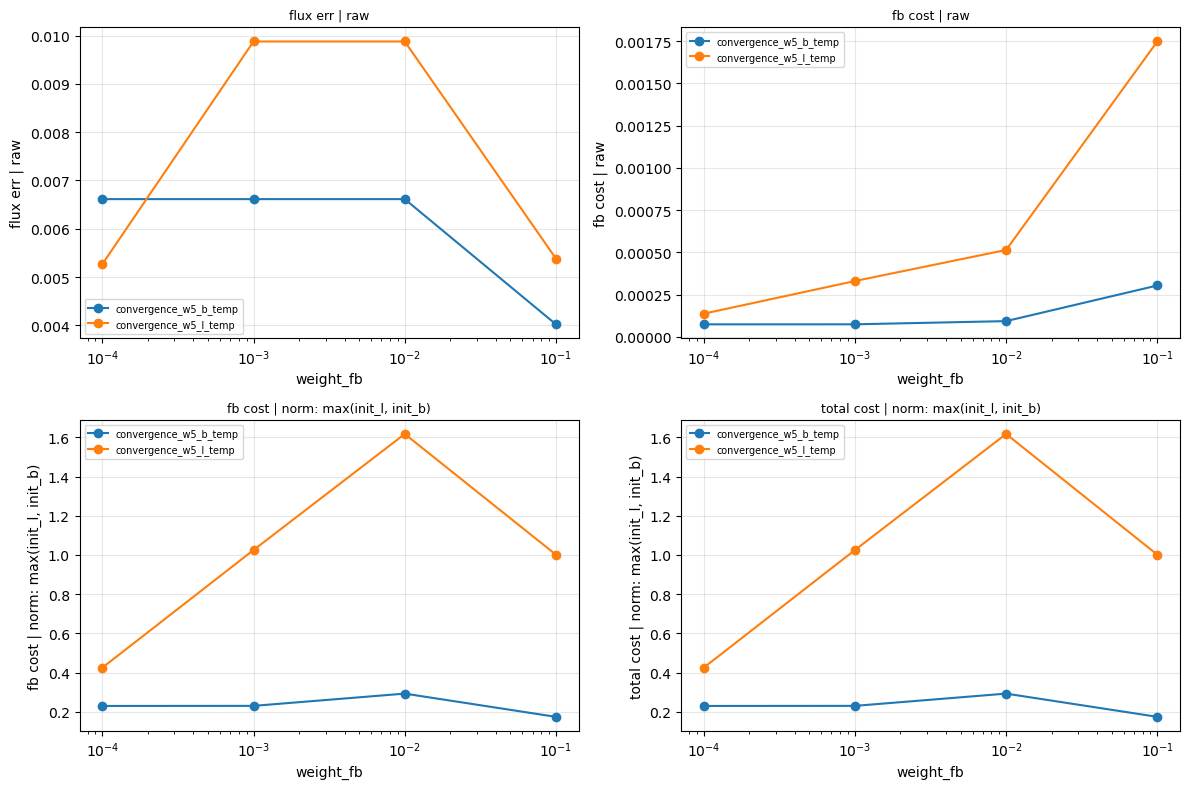

In [250]:
df['flux_shared'] = df['best_flux_err'] / df['norm_fixed']
df['fb_shared']   = df['best_fb_cost']  / df['norm_fb']

sweeps = df['sweep'].unique()

panels = [
    [('best_flux_err', 'flux err | raw'), ('best_fb_cost',     'fb cost | raw')],
    [('fb_shared',     'fb cost | norm: max(init_l, init_b)'), ('best_cost_shared', 'total cost | norm: max(init_l, init_b)')],
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), squeeze=False)
for row, cols in enumerate(panels):
    for col, (metric, ylabel) in enumerate(cols):
        ax = axes[row][col]
        for sweep in sweeps:
            sub = df[df['sweep'] == sweep].sort_values('weight_fb')
            ax.plot(sub['weight_fb'], sub[metric], marker='o', label=sweep)
        ax.set_xscale('log')
        ax.set_xlabel('weight_fb')
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel, fontsize=9)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


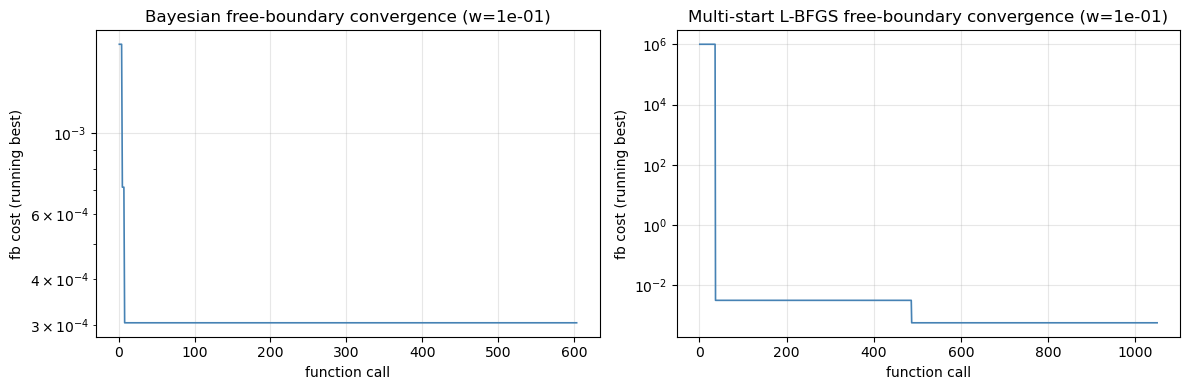

In [251]:
# bayesian vs lbfgs free-boundary convergence
PICK_WEIGHT = 1e-1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, method in zip(axes, ['Bayesian', 'Multi-start L-BFGS']):
    r = next(x for x in runs if x['method'] == method and abs(x['weight_fb'] - PICK_WEIGHT) < 1e-12)
    d = r['data']
    fb = np.array([x if x is not None else np.nan for x in d['fb_cost_history']], dtype=float)
    if r['method'] == 'Bayesian' and K_REFINED is not None:
        n_bay = d.get('n_bayesian_evals', 0)
        ref_evals = d.get('refinement_evals', [])
        trunc = n_bay + sum(ref_evals[:min(K_REFINED, len(ref_evals))])
        fb = fb[:trunc]
    rb = np.minimum.accumulate(np.where(np.isnan(fb), np.inf, fb))
    rb[rb == np.inf] = np.nan
    ax.plot(np.arange(1, len(rb)+1), rb, lw=1.2, color='steelblue')
    ax.set_yscale('log')
    ax.set_xlabel('function call')
    ax.set_ylabel('fb cost (running best)')
    ax.set_title(f'{method} free-boundary convergence (w={PICK_WEIGHT:.0e})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

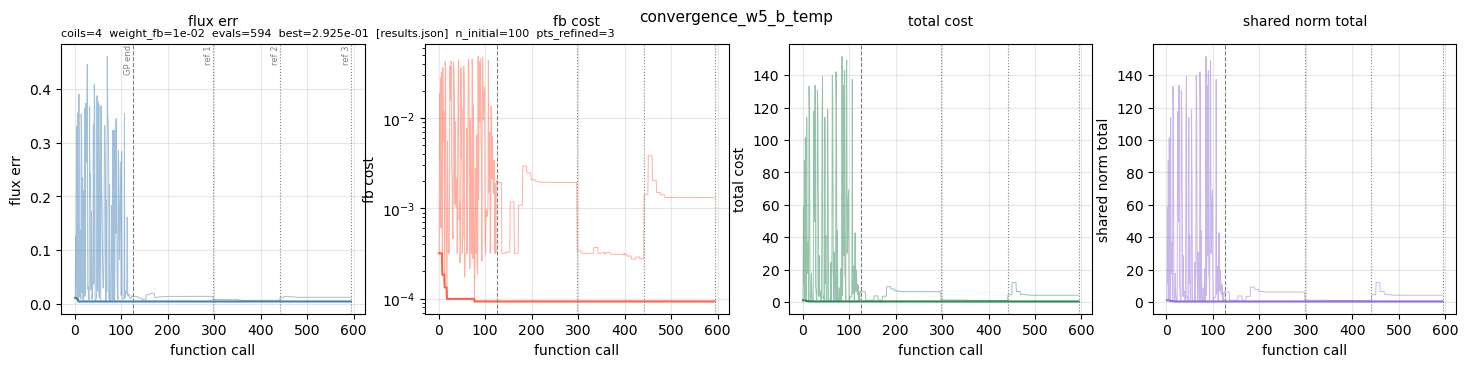

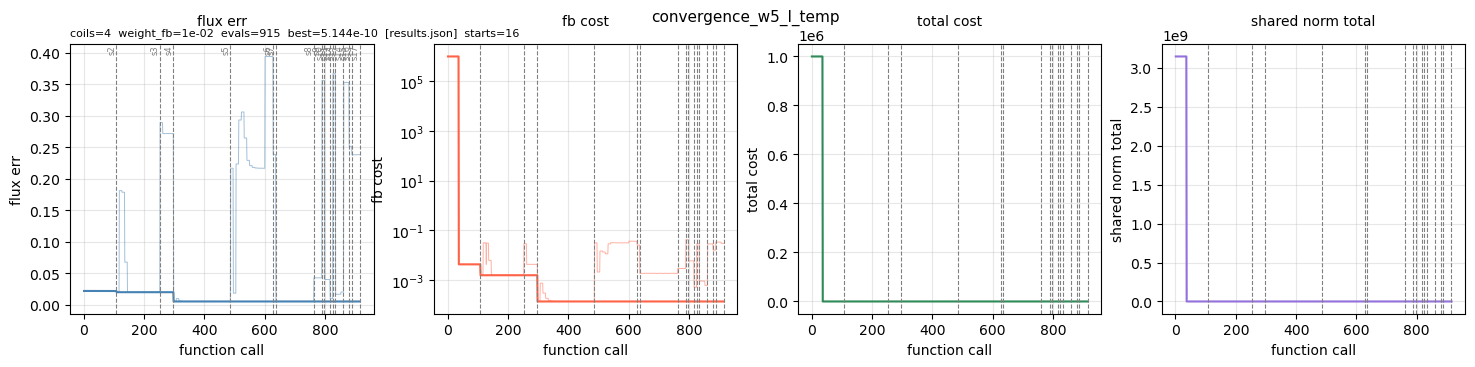

In [252]:
# --- filter ---
SHOW_SWEEPS = None   # None = all, or e.g. ['convergence_w5']
SHOW_WEIGHTS = [1e-2]  # None = all, or e.g. [1e-2, 1e-4]
SHOW_COILS = None    # None = all, or e.g. [3, 4]
CLIP = 1          # values >= this are plotted but ignored for ylim
SHOW_RAW = True  # plot half-transparent raw history alongside running-best
# --------------

filtered = [
    r for r in runs
    if (SHOW_SWEEPS is None or r['sweep'] in SHOW_SWEEPS)
    and (SHOW_WEIGHTS is None or any(abs(r['weight_fb'] - w) < 1e-12 for w in SHOW_WEIGHTS))
    and (SHOW_COILS is None or r['num_coils'] in SHOW_COILS)
]

norm_lookup = df.drop_duplicates('weight_fb').set_index('weight_fb')[['norm_fixed', 'norm_fb', 'alpha']]

COL_LABELS = ['flux err', 'fb cost', 'total cost', 'shared norm total']

for sweep in sorted(set(r['sweep'] for r in filtered)):
    sweep_runs = [r for r in filtered if r['sweep'] == sweep]
    n = len(sweep_runs)
    fig, axes = plt.subplots(n, 4, figsize=(18, 3.5 * n), sharex=False, squeeze=False)
    fig.suptitle(sweep, fontsize=11)

    for col, label in enumerate(COL_LABELS):
        axes[0][col].set_title(label, fontsize=10, pad=14)

    for row, r in enumerate(sorted(sweep_runs, key=lambda x: (x['num_coils'], x['weight_fb']))):
        d = r['data']
        total = np.array(d['cost_history'], dtype=float)
        flux = np.array([x if x is not None else np.nan for x in d['flux_err_history']], dtype=float)
        fb = np.array([x if x is not None else np.nan for x in d['fb_cost_history']], dtype=float)

        phase_lines = []

        if r['method'] == 'Bayesian':
            n_bay = d.get('n_bayesian_evals', 0)
            ref_evals = d.get('refinement_evals', [])
            k = len(ref_evals) if K_REFINED is None else min(K_REFINED, len(ref_evals))
            trunc = n_bay + sum(ref_evals[:k])
            total, flux, fb = total[:trunc], flux[:trunc], fb[:trunc]
            phase_lines.append(('GP end', n_bay, '--'))
            cumulative = n_bay
            for i, re in enumerate(ref_evals[:k]):
                cumulative += re
                phase_lines.append((f'ref {i+1}', cumulative, ':'))
            pts_label = k if K_REFINED is not None else d.get('pts_refined', '?')
            extra = f"  n_initial={d.get('n_initial','?')}  pts_refined={pts_label}"
        else:
            for i, x in enumerate(d.get('start_boundaries', [])):
                phase_lines.append((f's{i+2}', x, '--'))
            extra = f"  starts={d.get('starts_completed','?')}"

        w = r['weight_fb']
        norm_fixed = norm_lookup.loc[w, 'norm_fixed']
        norm_fb = norm_lookup.loc[w, 'norm_fb']
        alpha = norm_lookup.loc[w, 'alpha']
        shared_total = (1 - alpha) * flux / norm_fixed + alpha * fb / norm_fb

        evals = np.arange(1, len(total) + 1)
        run_title = f"coils={r['num_coils']}  weight_fb={w:.0e}  evals={len(total)}  best={np.nanmin(total):.3e}  [{r['source']}]{extra}"

        for ax, y, color, ylabel in zip(
            axes[row],
            [flux, fb, total, shared_total],
            ['steelblue', 'tomato', 'seagreen', 'mediumpurple'],
            COL_LABELS,
        ):
            if SHOW_RAW:
                ax.plot(evals, y, lw=0.7, alpha=0.5, color=color)
            running_best = np.minimum.accumulate(np.where(np.isnan(y), np.inf, y))
            running_best[running_best == np.inf] = np.nan
            ax.plot(evals, running_best, lw=1.5, color=color)
            ax.set_ylabel(ylabel)
            ax.grid(True, alpha=0.3)
            if row == len(sweep_runs) - 1:
                ax.set_xlabel('function call')

            if ylabel == 'fb cost':
                ax.set_yscale('log')

            for lbl, x, ls in phase_lines:
                ax.axvline(x, color='gray', lw=0.8, ls=ls)
                if ax is axes[row][0]:
                    ax.text(x, ax.get_ylim()[1], lbl, fontsize=6, ha='right',
                            va='top', rotation=90, color='gray')

        axes[row][0].annotate(run_title, xy=(0, 1), xycoords='axes fraction',
                              xytext=(0, 4), textcoords='offset points',
                              fontsize=8, va='bottom')


    plt.show()


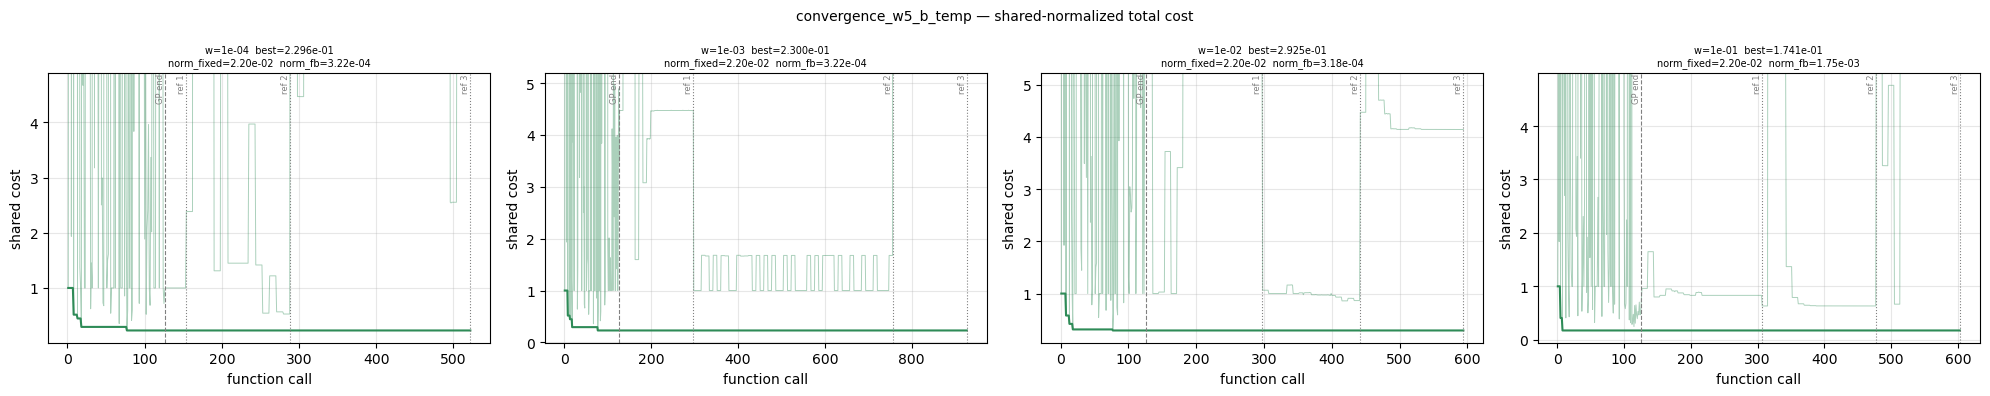

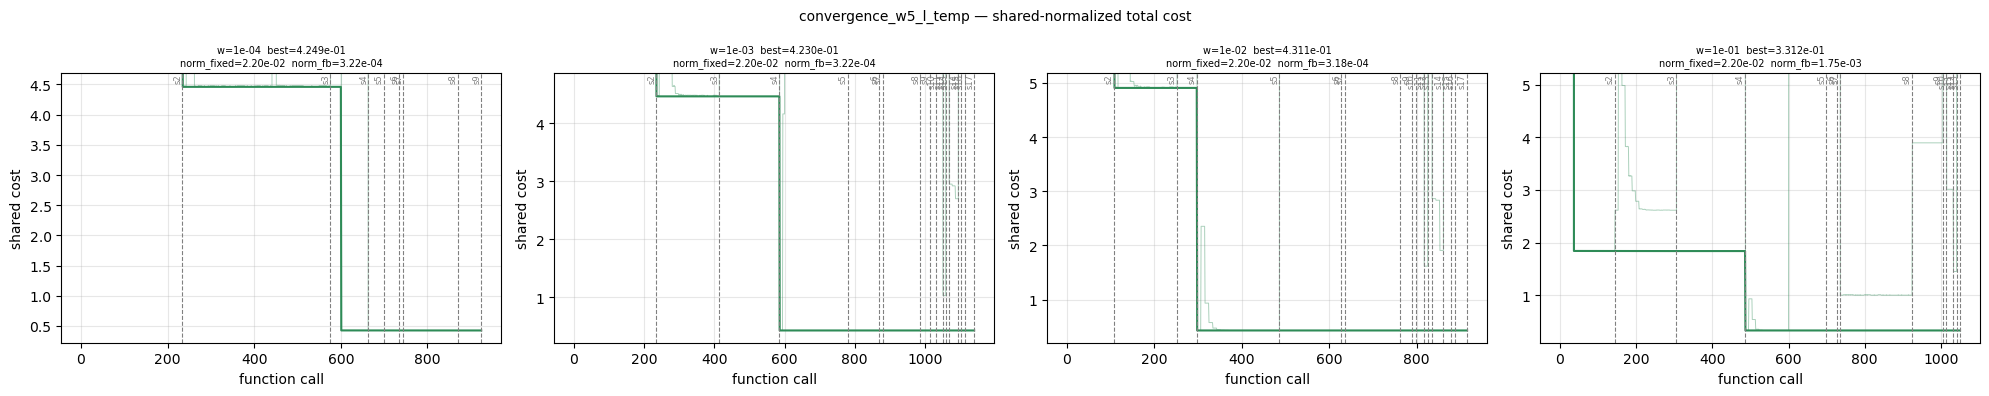

In [253]:
# shared-normalized total cost history (norm = max(init_lbfgs, init_bayesian) per weight_fb)
norm_lookup = df.drop_duplicates('weight_fb').set_index('weight_fb')[['norm_fixed', 'norm_fb', 'alpha']]
CLIP = 5

filtered = runs

for sweep in sorted(set(r['sweep'] for r in filtered)):
    sweep_runs = sorted([r for r in filtered if r['sweep'] == sweep], key=lambda x: x['weight_fb'])
    n = len(sweep_runs)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), squeeze=False)
    fig.suptitle(f"{sweep} — shared-normalized total cost", fontsize=10)

    for col, r in enumerate(sweep_runs):
        d = r['data']
        flux = np.array([x if x is not None else np.nan for x in d['flux_err_history']], dtype=float)
        fb = np.array([x if x is not None else np.nan for x in d['fb_cost_history']], dtype=float)

        phase_lines = []
        if r['method'] == 'Bayesian':
            n_bay = d.get('n_bayesian_evals', 0)
            ref_evals = d.get('refinement_evals', [])
            k = len(ref_evals) if K_REFINED is None else min(K_REFINED, len(ref_evals))
            trunc = n_bay + sum(ref_evals[:k])
            flux, fb = flux[:trunc], fb[:trunc]
            phase_lines.append(('GP end', n_bay, '--'))
            cum = n_bay
            for i, re in enumerate(ref_evals[:k]):
                cum += re
                phase_lines.append((f'ref {i+1}', cum, ':'))
        else:
            for i, x in enumerate(d.get('start_boundaries', [])):
                phase_lines.append((f's{i+2}', x, '--'))

        w = r['weight_fb']
        norm_fixed = norm_lookup.loc[w, 'norm_fixed']
        norm_fb = norm_lookup.loc[w, 'norm_fb']
        alpha = norm_lookup.loc[w, 'alpha']
        shared_total = (1 - alpha) * flux / norm_fixed + alpha * fb / norm_fb

        evals = np.arange(1, len(shared_total) + 1)
        ax = axes[0][col]
        ax.plot(evals, shared_total, lw=0.7, alpha=0.4, color='seagreen')
        rb = np.minimum.accumulate(np.where(np.isnan(shared_total), np.inf, shared_total))
        rb[rb == np.inf] = np.nan
        ax.plot(evals, rb, lw=1.5, color='seagreen')
        ax.set_ylabel('shared cost')
        ax.set_xlabel('function call')
        ax.grid(True, alpha=0.3)

        finite = shared_total[np.isfinite(shared_total) & (shared_total < CLIP)]
        if len(finite):
            pad = (finite.max() - finite.min()) * 0.05 or finite.min() * 0.05
            ax.set_ylim(finite.min() - pad, finite.max() + pad)

        for lbl, x, ls in phase_lines:
            ax.axvline(x, color='gray', lw=0.8, ls=ls)
            ax.text(x, ax.get_ylim()[1], lbl, fontsize=6, ha='right', va='top', rotation=90, color='gray')

        run_title = f"w={w:.0e}  best={np.nanmin(shared_total):.3e}\nnorm_fixed={norm_fixed:.2e}  norm_fb={norm_fb:.2e}"
        ax.set_title(run_title, fontsize=7)

    plt.tight_layout()
    plt.show()
